
# Chapter 12: XGBoost - regression models


### Importing the necessary packages

In [40]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeRegressor
import xgboost
from xgboost import XGBRegressor

import sklearn
from sklearn import tree
import matplotlib.pyplot as plt

### Plotting functions

In [41]:
# Some functions to plot our points and draw the lines
def plot_points(features, labels, fix_margins=True):
    X = np.array(features)
    y = np.array(labels)
    spam = X[np.argwhere(y==1)]
    ham = X[np.argwhere(y==0)]
    if fix_margins:
        plt.xlim(0, 11)
        plt.ylim(0, 11)
    plt.scatter([s[0][0] for s in spam],
                [s[0][1] for s in spam],
                s = 100,
                color = 'cyan',
                edgecolor = 'k',
                marker = '^')
    plt.scatter([s[0][0] for s in ham],
                [s[0][1] for s in ham],
                s = 100,
                color = 'red',
                edgecolor = 'k',
                marker = 's')
    plt.xlabel('Lottery')
    plt.ylabel('Sale')
    plt.legend(['Spam','Ham'])

def plot_model(X, y, model, fix_margins=True):
    X = np.array(X)
    y = np.array(y)
    plot_points(X, y)
    plot_step = 0.01
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    if fix_margins:
        x_min=0
        y_min=0
        x_max=12
        y_max=12
    xx, yy = np.meshgrid(np.arange(x_min, x_max, plot_step),
                         np.arange(y_min, y_max, plot_step))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, colors=['red', 'blue'], alpha=0.2, levels=range(-1,2))
    plt.contour(xx, yy, Z,colors = 'k',linewidths = 3)
    plt.show()

def display_tree(dt):
    import sys
    import six
    from IPython.display import Image
    from sklearn.tree import export_graphviz
    import pydotplus
    sys.modules['sklearn.externals.six'] = six
    dot_data = six.StringIO()
    export_graphviz(dt, out_file=dot_data,
                    filled=True, rounded=True,
                    special_characters=True)
    graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
    return Image(graph.create_png())

def plot_trees(model):
    estimators = gradient_boosting_model.estimators_
    for i in range(len(estimators)):
        tree.plot_tree(estimators[i][0])
        plt.show()
        #plot_model(new_X, new_y, estimators[i][0])

def plot_regressor(model, features, labels):
    x = np.linspace(0,85,1000)
    plt.scatter(features, labels)
    plt.plot(x, model.predict(x.reshape([-1,1])))
    plt.xlabel("Age")
    plt.ylabel("Days per week")
    plt.show()

### Loading dataset - The spam email dataset

In [42]:
features = np.array([[10],[20],[30],[40],[50],[60],[70],[80]])
labels = np.array([7,5,7,1,2,1,5,4])

### Defining and plotting our dataset

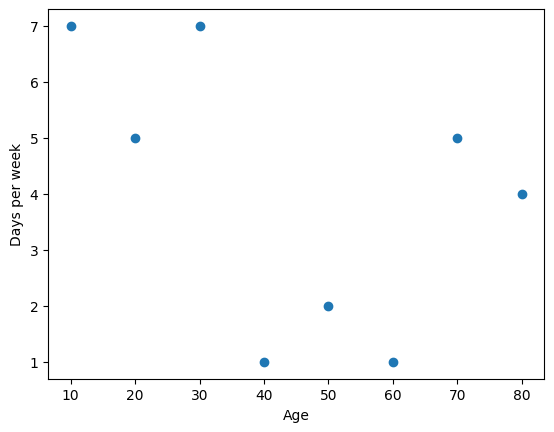

In [43]:
plt.scatter(features, labels)
plt.xlabel("Age")
plt.ylabel("Days per week")
plt.show()

### Fitting a decision tree

In [5]:
decision_tree_regressor = DecisionTreeRegressor(max_depth=2)
decision_tree_regressor.fit(features, labels)

DecisionTreeRegressor(max_depth=2)

### Ploting decision tree model

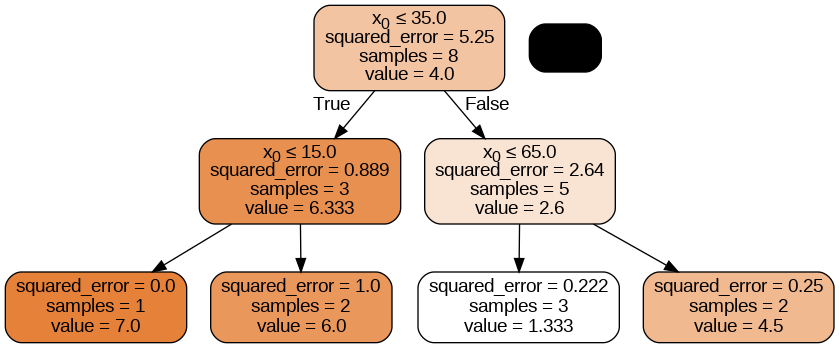

In [6]:
display_tree(decision_tree_regressor)

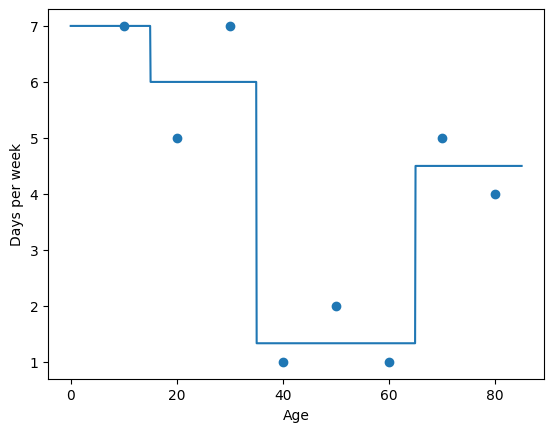

In [7]:
plot_regressor(decision_tree_regressor, features, labels)

## XGBoost

### First weak learner

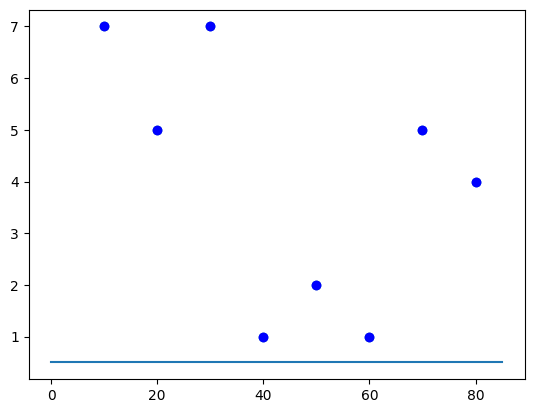

In [44]:
# First weak learner
x = np.linspace(0,85,2)
plt.scatter(features, labels)
plt.plot(x, [0.5 for i in range(len(x))])
plt.scatter(features, labels, color='blue')

### Traning XGBoost regressor

In [73]:
xgboost_regressor = XGBRegressor(random_state=0,
                             n_estimators=3, # Number of weak learners = n_estimators + first weak learner = 4
                             max_depth=2, # Max depth of Decision tree (weak learner)
                             reg_lambda=0, # The number added to the denominator of the similarity score
                             min_split_loss=1, # The minimum gain in similarity score to allow for a split to happen
                             learning_rate=0.7) # learning rate
xgboost_regressor.fit(features, labels)
xgboost_regressor.score(features, labels)

0.9013694524765015

### Plot the model

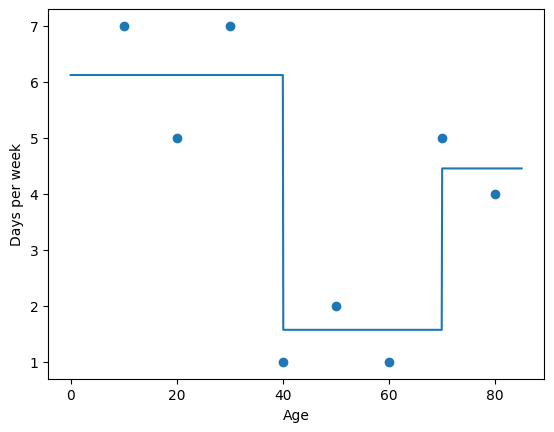

In [74]:
plot_regressor(xgboost_regressor, features, labels)

### Plot individual weak learners from Gradient boosting model

/usr/local/lib/python3.12/dist-packages/xgboost/plotting.py:267: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


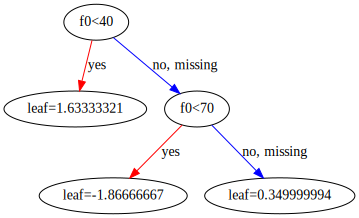

In [53]:
xgboost.to_graphviz(xgboost_regressor, num_trees=0)

/usr/local/lib/python3.12/dist-packages/xgboost/plotting.py:267: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


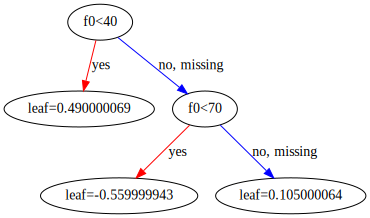

In [17]:
xgboost.to_graphviz(xgboost_regressor, num_trees=1)

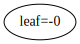

In [77]:
xgboost.to_graphviz(xgboost_regressor, num_trees=2)

In [19]:
xgboost_regressor.predict(features)

array([6.1233335, 6.1233335, 6.1233335, 1.5733333, 1.5733333, 1.5733333,
       4.455    , 4.455    ], dtype=float32)

### Calculations of similarity score by hand

In [20]:
residuals = labels-0.5
residuals

array([6.5, 4.5, 6.5, 0.5, 1.5, 0.5, 4.5, 3.5])

In [21]:
def score(l, lam=0):
    if len(l)==0:
        return 0
    return sum(l)**2/(len(l)+lam)

In [22]:
score(residuals, lam=0)

np.float64(98.0)

In [23]:
lam = 0
for i in range(len(residuals)):
    left = residuals[:i]
    right = residuals[i:]
    print(left, right)
    print(score(left), score(right))
    print(score(left, lam)+score(right, lam))
    print()

[] [6.5 4.5 6.5 0.5 1.5 0.5 4.5 3.5]
0 98.0
98.0

[6.5] [4.5 6.5 0.5 1.5 0.5 4.5 3.5]
42.25 66.03571428571429
108.28571428571429

[6.5 4.5] [6.5 0.5 1.5 0.5 4.5 3.5]
60.5 48.166666666666664
108.66666666666666

[6.5 4.5 6.5] [0.5 1.5 0.5 4.5 3.5]
102.08333333333333 22.05
124.13333333333333

[6.5 4.5 6.5 0.5] [1.5 0.5 4.5 3.5]
81.0 25.0
106.0

[6.5 4.5 6.5 0.5 1.5] [0.5 4.5 3.5]
76.05 24.083333333333332
100.13333333333333

[6.5 4.5 6.5 0.5 1.5 0.5] [4.5 3.5]
66.66666666666667 32.0
98.66666666666667

[6.5 4.5 6.5 0.5 1.5 0.5 4.5] [3.5]
85.75 12.25
98.0



In [24]:
left_tree = [6.5, 4.5, 6.5]
right_tree = [0.5, 1.5, 0.5, 4.5, 3.5]

In [25]:
residuals = left_tree
print(score(residuals))
for i in range(len(residuals)):
    left = residuals[:i]
    right = residuals[i:]
    print(left, right)
    print(score(left), score(right))
    print(score(left, lam)+score(right, lam))
    print()

102.08333333333333
[] [6.5, 4.5, 6.5]
0 102.08333333333333
102.08333333333333

[6.5] [4.5, 6.5]
42.25 60.5
102.75

[6.5, 4.5] [6.5]
60.5 42.25
102.75



In [26]:
residuals = right_tree
print(residuals)
for i in range(len(residuals)):
    left = residuals[:i]
    right = residuals[i:]
    print(left, right)
    print(score(left), score(right))
    print(score(left, lam)+score(right, lam))
    print()

[0.5, 1.5, 0.5, 4.5, 3.5]
[] [0.5, 1.5, 0.5, 4.5, 3.5]
0 22.05
22.05

[0.5] [1.5, 0.5, 4.5, 3.5]
0.25 25.0
25.25

[0.5, 1.5] [0.5, 4.5, 3.5]
2.0 24.083333333333332
26.083333333333332

[0.5, 1.5, 0.5] [4.5, 3.5]
2.0833333333333335 32.0
34.083333333333336

[0.5, 1.5, 0.5, 4.5] [3.5]
12.25 12.25
24.5

